# Engenharia de atributos e EDA das variáveis criadas

Neste terceiro notebook da série v4, é executada e auditada a etapa de **engenharia de atributos**. As transformações determinísticas são aplicadas pelo `build_preprocessing_pipeline`, e a utilidade descritiva das variáveis derivadas é examinada antes da seleção supervisionada realizada na modelagem.

Para que o crescimento histórico da operação não seja confundido com efeito de calendário ou de clima, as distribuições de demanda são avaliadas sobre o **índice des-tendenciado** produzido por `src.seasonal.demand_index_moving_average`. A demanda horária é dividida por uma linha de base móvel centrada de 365 dias, estimada sobre médias diárias. Assim, é preservada uma leitura multiplicativa em torno de 1, enquanto a mudança estrutural de nível é removida da comparação.

A análise é retrospectiva. Como observações futuras são consultadas pela janela centrada, o índice não é tratado como atributo operacional. Também não são atribuídos efeitos causais às diferenças observadas: horário, estação, precipitação e variáveis térmicas permanecem inter-relacionados.


In [1]:
import logging
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import read_data
from src.feature_engineering import build_preprocessing_pipeline
from src.plotting import set_graph_parameters
from src.i18n import make_lang
from src import feature_eda as fe

warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

lang = make_lang('pt')          # PT canônico — passthrough, sem chamadas de rede
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

TARGET = 'Rented Bike Count'
INDEX = 'Demand_Index'

raw = read_data()
df = build_preprocessing_pipeline().fit_transform(raw.copy())

msg = lang({'rows': 'Linhas', 'raw_cols': 'Colunas brutas',
            'eng_cols': 'colunas após a engenharia', 'period': 'Período', 'to': 'a'})
print(f'{msg["rows"]}: {len(df):,}')
print(f'{msg["raw_cols"]}: {raw.shape[1]} | {msg["eng_cols"]}: {df.shape[1]}')
print(f'{msg["period"]}: {df["Date"].min():%d/%m/%Y %H:%M} {msg["to"]} '
      f'{df["Date"].max():%d/%m/%Y %H:%M}')


Linhas: 81,018
Colunas brutas: 17 | colunas após a engenharia: 27
Período: 19/09/2015 00:00 a 31/12/2024 23:00


## 1. Auditoria das variáveis criadas pelo pipeline

São derivados atributos de calendário, período do dia, condição operacional e faixas meteorológicas. A coluna `Date` é preservada como índice temporal; `Month` e `Year` são extraídos do timestamp; e as representações categóricas são mantidas com os rótulos do contrato já utilizado pelo pipeline.

Nesta EDA, os valores ausentes não são imputados globalmente. As estatísticas são calculadas com os casos disponíveis, e a ausência é explicitada nas contagens. Na modelagem, a imputação deve continuar sendo ajustada somente sobre o subconjunto de treino de cada divisão temporal.

A definição anterior de `Rush_Hour` também foi auditada. `Functioning Day` estava sendo usado como se indicasse dia útil, o que permitia que fins de semana fossem marcados como pico. A regra foi corrigida para exigir simultaneamente dia de semana, operação ativa e ausência de feriado. Além disso, foi criada `Rush_Period`, pela qual os picos da manhã e da tarde/noite são preservados separadamente.


In [2]:
inventory = fe.created_features_inventory(df, lang=lang)
display(inventory)

missing = fe.missing_features_summary(df, lang=lang)
display(missing.style.format({'Percentual': '{:.2f}%'}))

audit = fe.rush_hour_audit(df)
msg = lang({
    'legacy': 'Fins de semana classificados como pico pela regra anterior',
    'revised': 'Fins de semana classificados como pico pela regra revisada',
})
print(f'{msg["legacy"]}: {audit["legacy_weekend"]:,}')
print(f'{msg["revised"]}: {audit["revised_weekend"]:,}')


,Variável,Presente,Tipo,Valores distintos,Ausentes
0,Date,True,datetime64[ns],81018,0
1,Time_Period,True,category,4,0
2,Weekday,True,category,7,0
3,DayNumberOnWeek,True,int32,7,0
4,WeekStatus,True,category,2,0
5,Rush_Hour,True,category,2,0
6,Rush_Period,True,category,3,0
7,Rainfall Cat,True,category,4,0
8,Snowfall Cat,True,category,4,0
9,Sunshine Cat,True,category,4,0


,Ausentes,Percentual
Cloud Cover (oktas),5482,6.77%
Cloud Cover Cat,5482,6.77%
Wind speed (m/s),123,0.15%
Ground Temp(C),32,0.04%
Temperature(C),5,0.01%
Humidity(%),4,0.00%
Dew point temperature(C),2,0.00%
Visibility (10m),1,0.00%


Fins de semana classificados como pico pela regra anterior: 6,487
Fins de semana classificados como pico pela regra revisada: 0


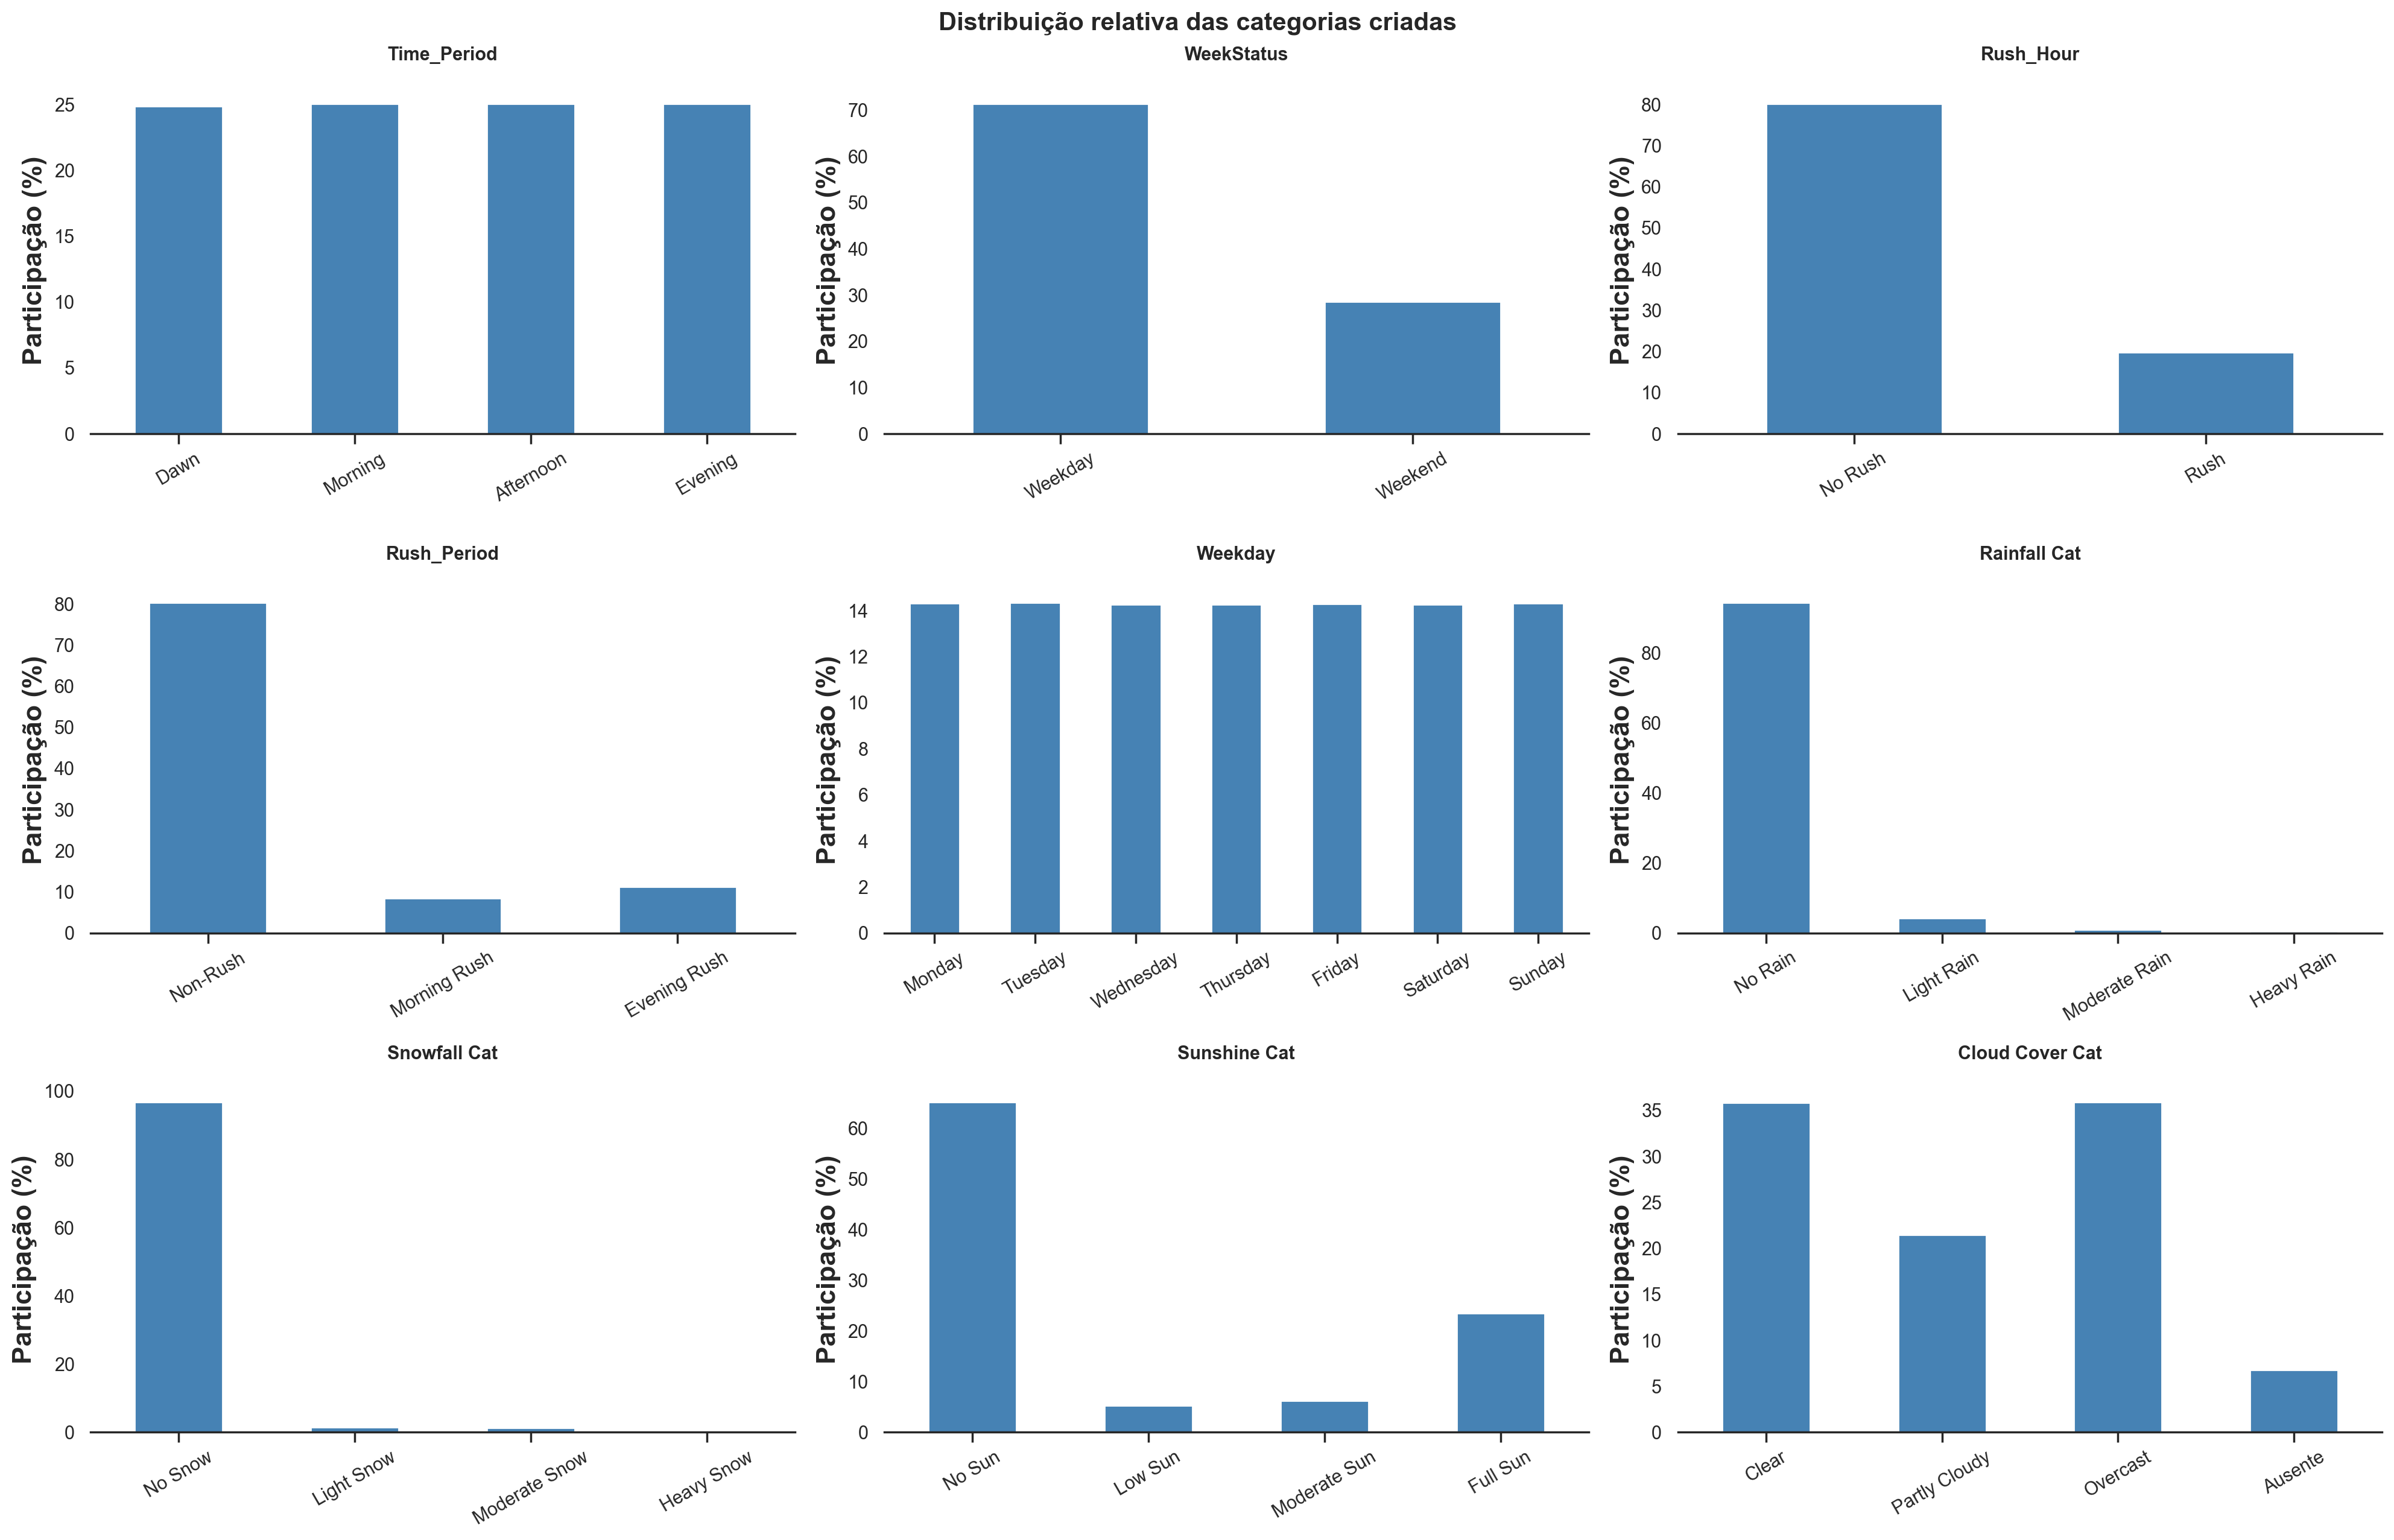

In [3]:
fig, axes = fe.plot_category_distribution(df, lang=lang)
plt.show()


>### Insight
>
> Foram confirmadas 13 variáveis derivadas. A maior ausência foi concentrada em `Cloud Cover (oktas)` e, por consequência, em `Cloud Cover Cat`; essa ausência foi mantida visível nesta etapa, em vez de ser preenchida com uma estatística calculada sobre todo o período.
>
> Pela auditoria da regra de pico, 6.487 linhas de fim de semana teriam sido classificadas como `Rush` pela implementação anterior. Após ter sido exigido `WeekStatus == 'Weekday'`, nenhum fim de semana permaneceu nessa classe. A nova `Rush_Period` foi integrada ao espaço categórico do otimizador para que a diferença entre os picos matinal e vespertino possa ser avaliada pelos seletores dentro da validação temporal.


## 2. Alvo descritivo: índice de demanda des-tendenciado

A demanda bruta é convertida no índice multiplicativo $I_t = Y_t / \widehat{T}_t$, em que $\widehat{T}_t$ corresponde à média móvel **centrada** da demanda diária em uma janela de 365 dias. A agregação diária impede que a janela seja interpretada equivocadamente como 365 horas, e a extensão anual permite que o nível estrutural seja acompanhado sem que toda a variação sazonal seja removida.

A construção segue a lógica da decomposição por razão à média móvel. Os meses de 2020 cuja demanda média ficou abaixo de 60% da média geométrica entre os mesmos meses de 2019 e 2021 são excluídos apenas da estimação da linha de base. Suas observações permanecem no índice, evitando que o regime anômalo rebaixe artificialmente a referência contra a qual ele próprio é comparado.

A média geométrica foi adotada porque o crescimento da demanda ocorre predominantemente de forma multiplicativa. Desse modo, $(\sqrt{Y_{2019,m}Y_{2021,m}})$ representa a interpolação do nível esperado para 2020 na escala logarítmica. Diferentemente da média aritmética, essa referência não é excessivamente deslocada pelo nível mais elevado de 2021.

Por exemplo, entre valores de 100 e 400, uma trajetória com crescimento proporcional constante produziria 200 como ponto intermediário, valor obtido pela média geométrica; pela média aritmética, seriam obtidos 250.

As bordas sem quantidade mínima de dias para a média móvel são descartadas da EDA. A demanda original é preservada em `Rented Bike Count`, enquanto o índice é armazenado separadamente em `Demand_Index`; assim, deixa de ser produzida a ambiguidade de sobrescrever o alvo bruto com uma medida transformada.


In [4]:
mv, demand_index, anomaly_mask = fe.detrended_index_frame(df, TARGET, INDEX)
display(fe.detrend_diagnostics(df, mv, demand_index, anomaly_mask, TARGET, INDEX, lang=lang))


,Diagnóstico
Meses anômalos de 2020,"5, 6, 7, 8, 9, 10, 11, 12"
Linhas preservadas,"75,304 (92.9%)"
Crescimento médio 2015→2024,106.8×
Média do índice,0.972
Mediana do índice,0.717
Amplitude das médias mensais,1.108


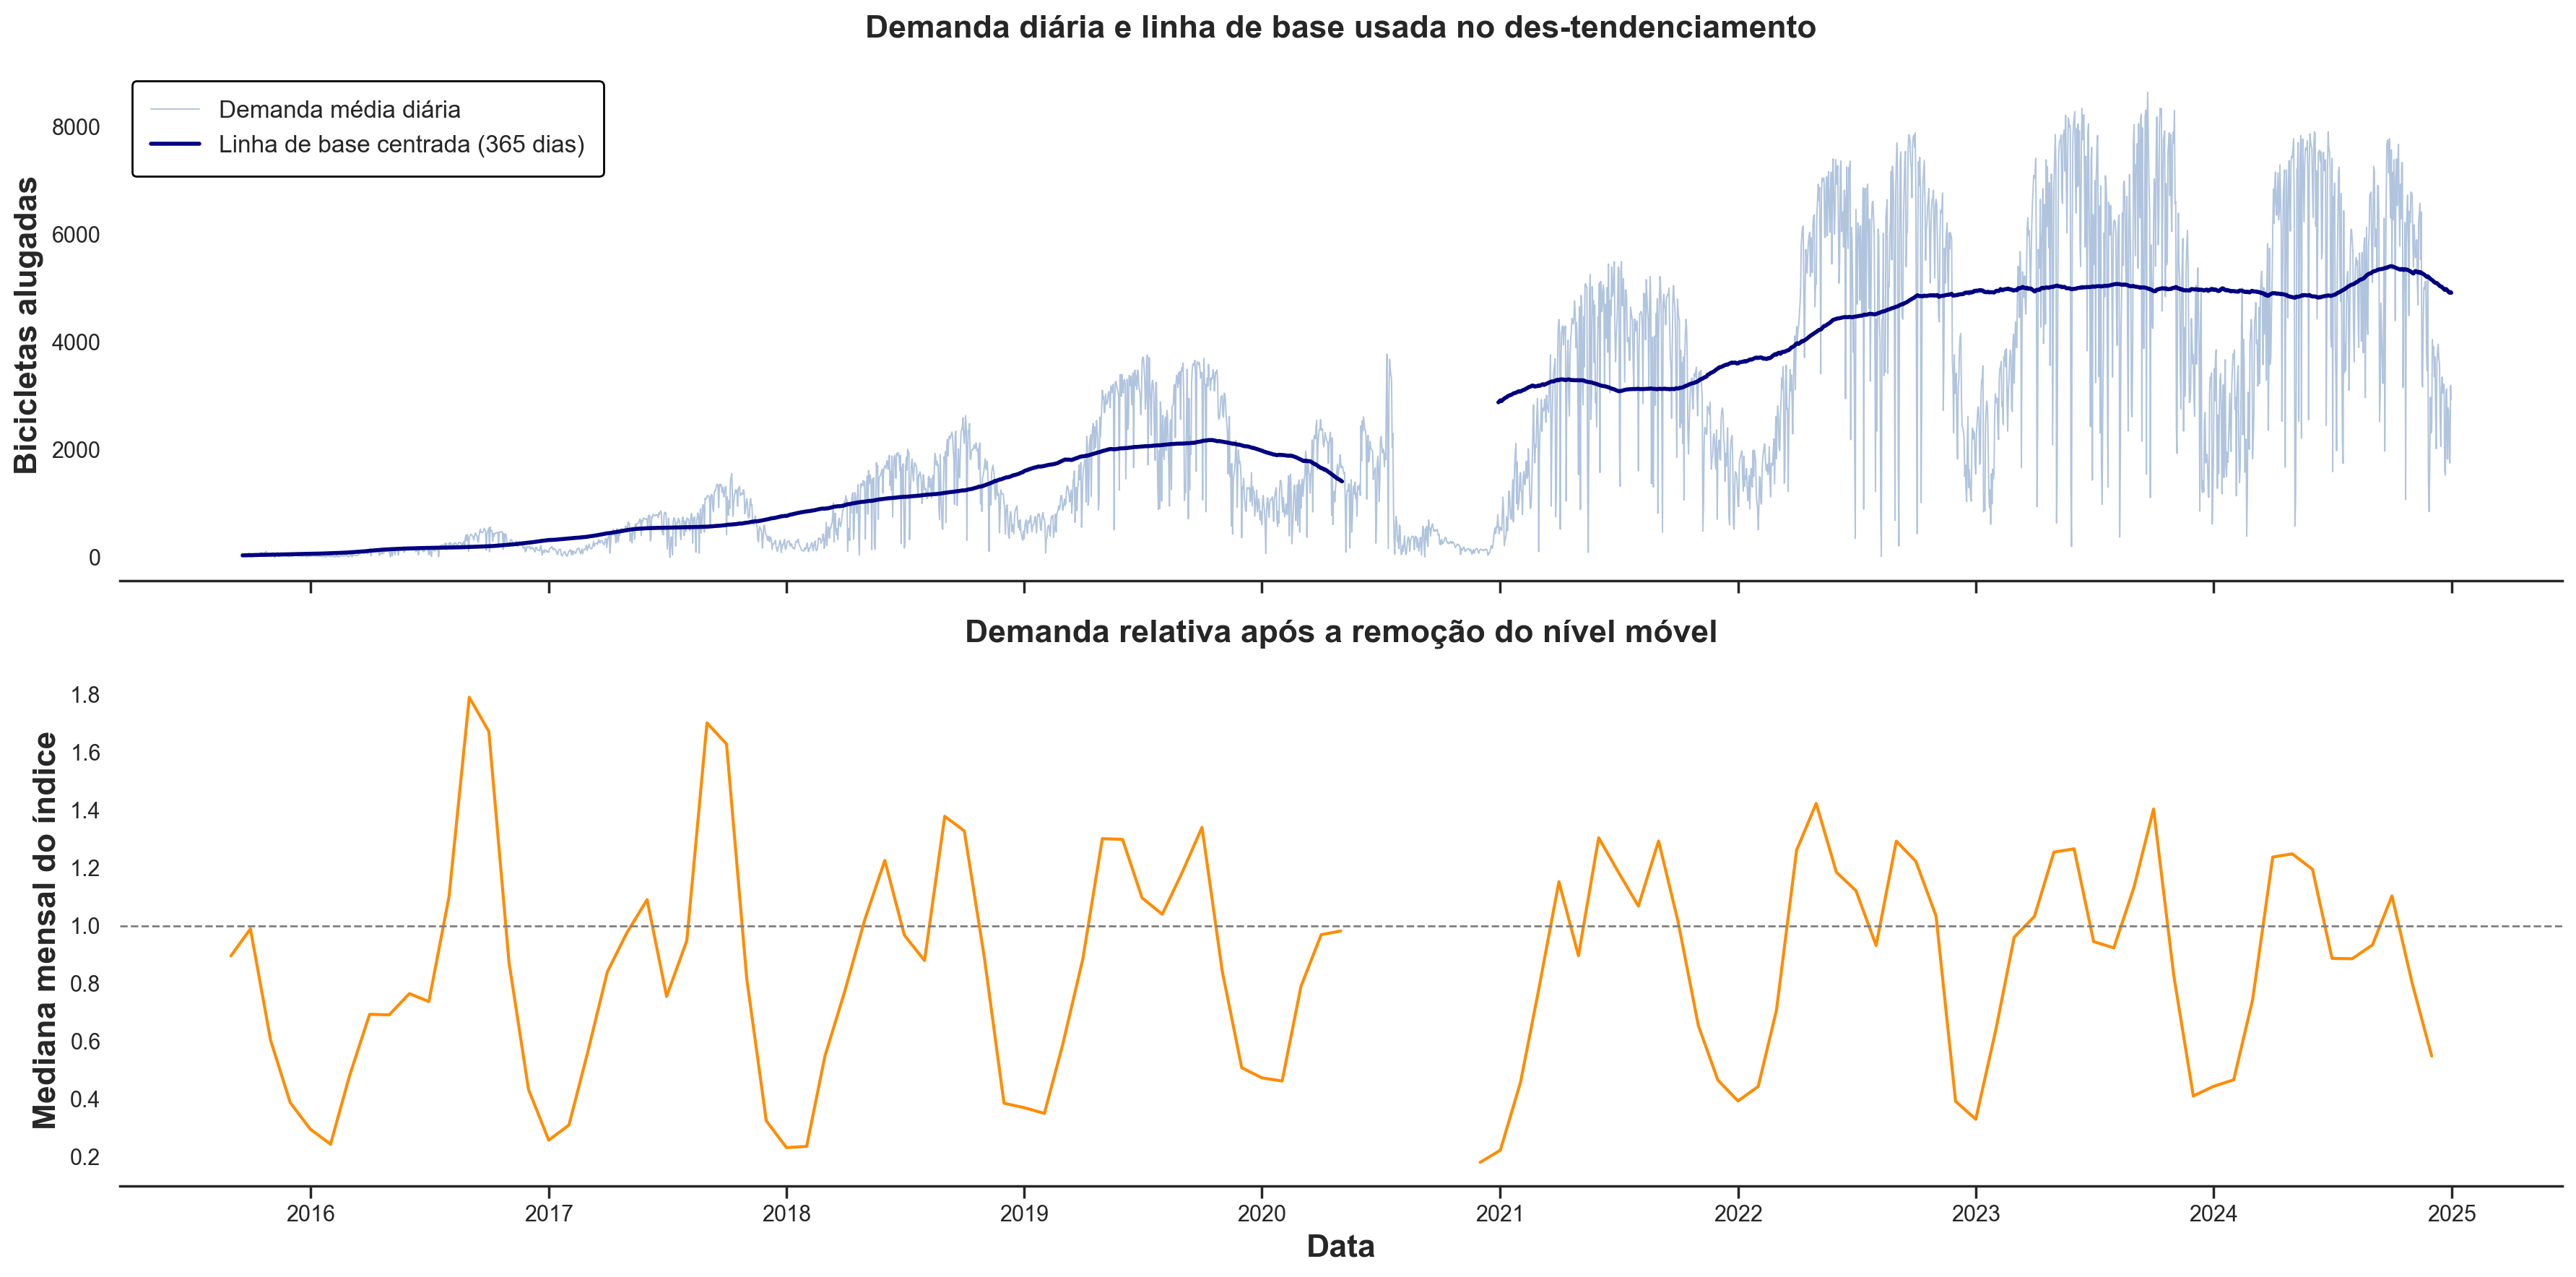

In [5]:
fig, axes = fe.plot_detrend_baseline(df, mv, anomaly_mask, TARGET, INDEX, lang=lang)
plt.show()


>### Insight
>
> Foi observado crescimento médio de aproximadamente 106,8 vezes entre 2015 e 2024, enquanto 92,9% das linhas permaneceram disponíveis após a exigência mínima da janela centrada. Por isso, comparações feitas diretamente sobre a contagem bruta seriam dominadas pelo ano de observação, e não apenas pela categoria examinada.
>
> A amplitude de 1,11 entre as médias mensais do índice mostrou que a sazonalidade não foi eliminada pela linha de base anual. O índice foi mantido exclusivamente como alvo descritivo retrospectivo, pois sua média móvel centrada incorpora informação posterior ao instante analisado e produziria vazamento se fosse oferecida ao estimador operacional.


## 3. Demanda relativa por variável criada

São comparadas as distribuições de `Demand_Index` entre os níveis das nove variáveis categóricas derivadas. A linha de referência em 1 representa o nível da linha de base móvel: valores superiores indicam demanda acima dessa referência local, e valores inferiores indicam demanda abaixo dela.

Para que a escala comum seja legível, os pontos classificados como *fliers* pelo boxplot não são desenhados, mas nenhuma observação é removida dos cálculos. As medianas, os quartis e o tamanho de cada grupo são calculados separadamente; dessa forma, diferenças grandes sustentadas por poucas ocorrências podem ser distinguidas de padrões recorrentes.


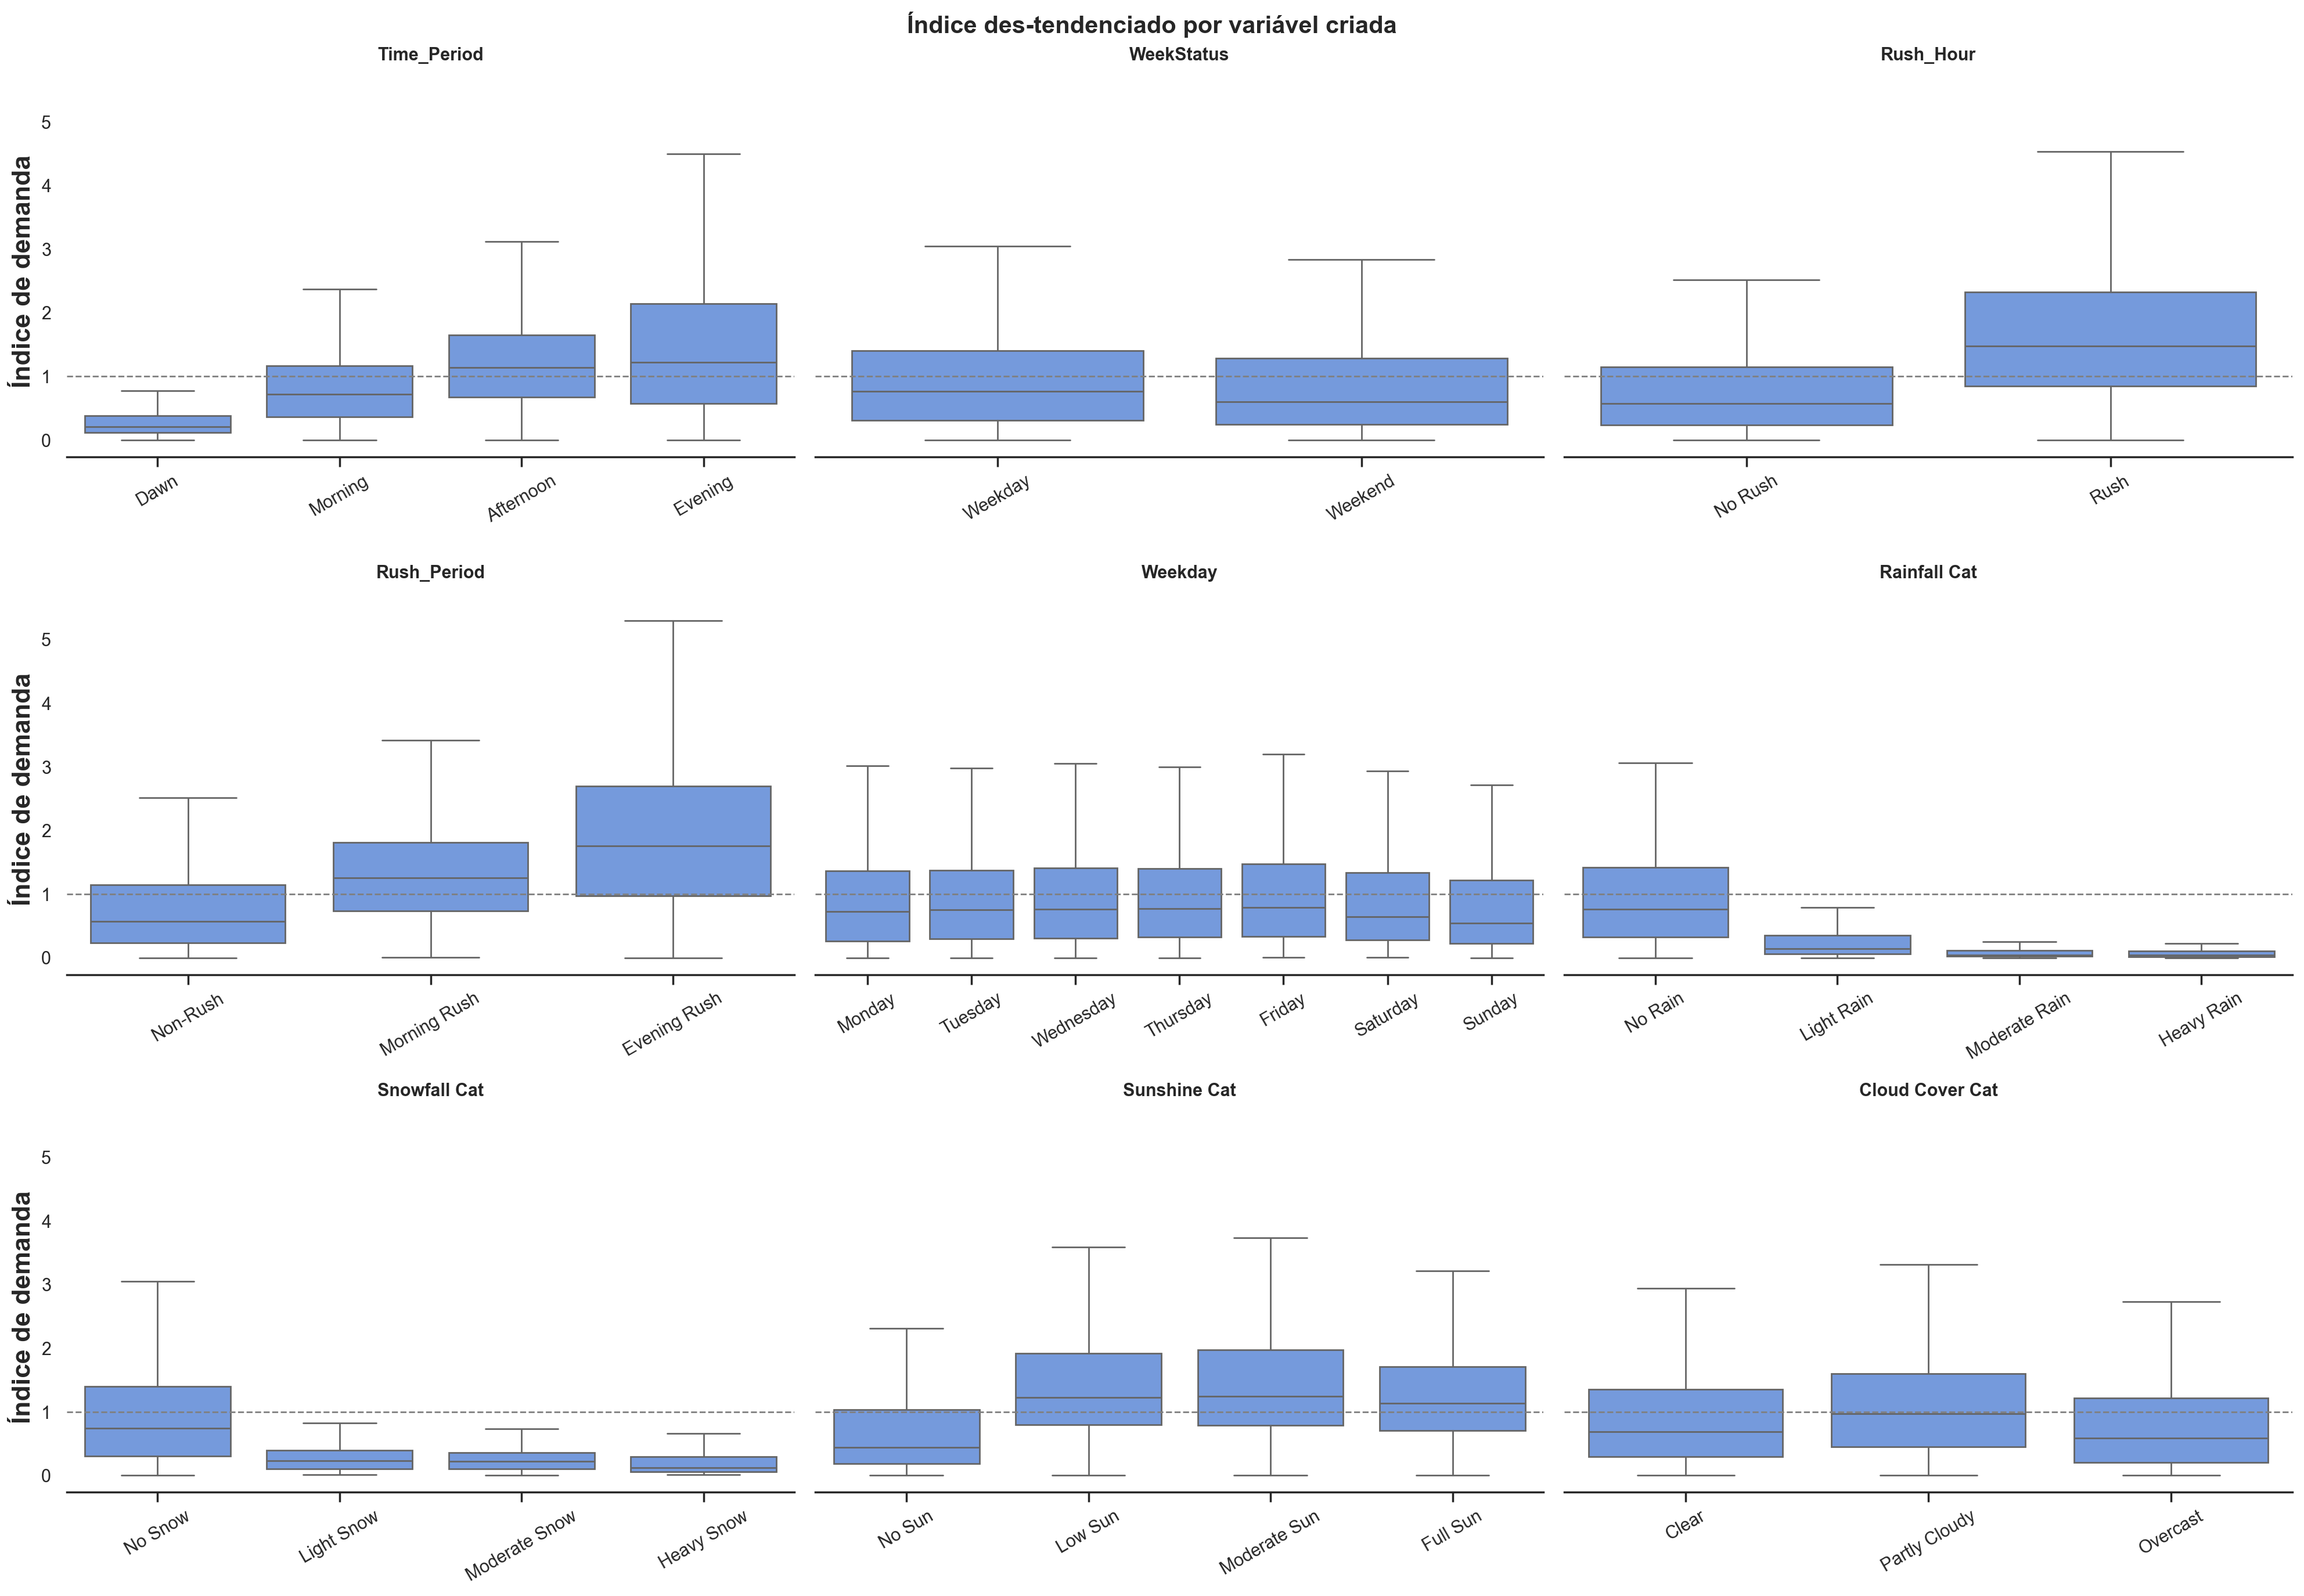

In [6]:
fig, axes = fe.plot_category_boxplots(mv, index_col=INDEX, lang=lang)
plt.show()


In [7]:
effect_summary, category_effects = fe.category_effect_summary(mv, index_col=INDEX, lang=lang)
display(
    fe.localize_feature_table(effect_summary, lang=lang).style
    .background_gradient(cmap='Blues', subset=['Amplitude'])
    .format({'Valor mínimo': '{:.3f}', 'Valor máximo': '{:.3f}', 'Amplitude': '{:.3f}'})
)


,Variável,Menor mediana,Valor mínimo,Maior mediana,Valor máximo,Amplitude,Menor n por nível
3,Rush_Period,Non-Rush,0.575,Evening Rush,1.763,1.188,6380
0,Time_Period,Dawn,0.210,Evening,1.219,1.008,18716
2,Rush_Hour,No Rush,0.575,Rush,1.475,0.901,14878
7,Sunshine Cat,No Sun,0.447,Moderate Sun,1.244,0.797,3896
5,Rainfall Cat,Heavy Rain,0.040,No Rain,0.766,0.726,331
6,Snowfall Cat,Heavy Snow,0.127,No Snow,0.748,0.621,322
8,Cloud Cover Cat,Overcast,0.588,Partly Cloudy,0.969,0.380,16092
4,Weekday,Sunday,0.550,Friday,0.795,0.245,10740
1,WeekStatus,Weekend,0.599,Weekday,0.762,0.163,21522


>### Insight
>
> A maior separação descritiva foi obtida para `Rush_Period`: a mediana passou de 0,575 em `Non-Rush` para 1,260 no pico da manhã e 1,763 no pico da tarde/noite. Ao serem combinados os dois picos em `Rush_Hour`, a amplitude foi reduzida para 0,901. Foi demonstrado, portanto, que a nova feature preserva uma assimetria relevante que era ocultada pela representação binária.
>
> Também foram observadas amplitudes elevadas para `Time_Period` (1,008), `Sunshine Cat` (0,797), `Rainfall Cat` (0,726) e `Snowfall Cat` (0,621). Entretanto, os níveis mais intensos de chuva e neve foram representados por apenas algumas centenas de observações. Essas amplitudes são descritivas, não ajustadas e não devem ser lidas como efeito causal isolado.
>
> As menores amplitudes foram obtidas para `WeekStatus` e `Weekday`. Ainda assim, sua exclusão manual não foi determinada: a redundância com hora, período do dia e pico será avaliada por `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` e `NoSelector` dentro de cada configuração de estimador.


### 3.1 Inspeção do `MeanEncoder`

O `MeanEncoder`, disponibilizado por `feature_engine` e incluído no espaço de busca do otimizador, implementa uma forma não regularizada de *target encoding*. Cada nível $c$ é substituído pela média do alvo observada no conjunto usado no ajuste, $\widehat{\mu}_c = n_c^{-1}\sum_{i:X_i=c} y_i$.

A tabela seguinte é apenas um diagnóstico. Nela, o encoder é simulado sobre `Demand_Index`, e médias por estação são acrescentadas para que a estabilidade do padrão seja examinada. Na modelagem real, o alvo, o período de treino e, portanto, os valores codificados são outros. A coluna `Geral` não deve ser interpretada como o mapeamento definitivo entregue ao modelo.

Como a transformação é supervisionada, o ajuste deve ser realizado dentro de cada fold. Se as médias fossem calculadas antes da separação temporal, o alvo de validação seria incorporado à própria feature. A mesma restrição impede que médias específicas do ano ou da estação retida sejam calculadas com seus próprios alvos.


In [8]:
mean_encoding_by_season = fe.mean_encoding_by_season(mv, index_col=INDEX, lang=lang)
season_labels = ['Inverno', 'Primavera', 'Verão', 'Outono']
display(
    fe.localize_feature_table(mean_encoding_by_season, lang=lang).style
    .background_gradient(cmap='RdYlBu_r', subset=season_labels + ['Geral'], axis=None)
    .format({col: '{:.3f}' for col in season_labels + ['Geral', 'Amplitude entre estações']})
    .format({'n': '{:,.0f}'})
)


#### Separação produzida dentro de cada estação

Pela leitura anterior, é medida a variação do mesmo nível entre estações. A leitura complementar abaixo é calculada na direção oposta: para cada estação, é obtida a amplitude entre os níveis de uma feature. Assim, é verificado se a capacidade de separação permanece estável ou depende do contexto sazonal.


In [9]:
within_season_spread = fe.within_season_spread(mv, index_col=INDEX, lang=lang)
display(
    fe.localize_feature_table(within_season_spread, lang=lang).style
    .background_gradient(cmap='Greens', axis=None)
    .format('{:.3f}')
)


Seasons,Inverno,Primavera,Verão,Outono
Variável,,,,
Time_Period,0.463,1.191,1.627,1.497
WeekStatus,0.115,0.113,0.154,0.106
Rush_Hour,0.458,0.966,1.020,1.064
Rush_Period,0.508,1.264,1.329,1.351
Weekday,0.150,0.142,0.278,0.214
Rainfall Cat,0.419,1.027,1.143,1.196
Snowfall Cat,0.309,0.982,0.000,0.896
Sunshine Cat,0.381,0.882,0.675,0.865
Cloud Cover Cat,0.127,0.354,0.371,0.342


In [10]:
verification = fe.meanencoder_verification(
    mv, mean_encoding_by_season, index_col=INDEX, demo_col='Rush_Period', lang=lang)
display(verification.style.format('{:.6f}'))


,MeanEncoder demonstrativo,Geral da tabela,Diferença absoluta
Nível,,,
Evening Rush,1.906264,1.906264,0.000000
Morning Rush,1.360941,1.360941,0.000000
Non-Rush,0.799171,0.799171,0.000000


>### Insight
>
> Foi verificado que `Geral` reproduz exatamente o `MeanEncoder` apenas para o quadro demonstrativo, no qual o índice completo foi usado como alvo. Essa igualdade valida a mecânica da inspeção, mas não representa os valores aprendidos nos folds do modelo.
>
> A separação produzida por `Rush_Period`, `Time_Period` e precipitação foi muito menor no inverno do que nas demais estações. Foi evidenciada, assim, uma interação sazonal que uma única média global não representa. Essa limitação poderá ser absorvida por estimadores não lineares ou por interações selecionadas, mas não criação deliberadamente médias estação–alvo fora dos folds. 
>
> Como a média simples não aplica suavização, maior instabilidade pode ser produzida pelos níveis raros de chuva e neve. Por isso, `MeanEncoder` é mantido como uma alternativa do espaço de busca, ao lado de codificadores regularizados e não supervisionados, e não como escolha fixa baseada nesta tabela *in-sample*.


## 4. Colunas meteorológicas: insolação, nebulosidade e temperatura do solo

São examinadas `Sunshine (hr)`, `Cloud Cover (oktas)` e `Ground Temp(C)`. Para as variáveis com poucos valores possíveis, as relações são resumidas por valor observado; para a temperatura do solo, são utilizados quantis com tamanhos semelhantes. Mediana e intervalo interquartil são apresentados para que a forma da associação não seja reduzida a uma única média.

As correlações de Spearman são usadas somente como medida monotônica bivariada. Horário, mês, estação e temperatura do ar não são controlados nesse cálculo. Consequentemente, uma associação entre insolação e demanda pode refletir simultaneamente presença de luz diurna, condições de tempo e período do dia.


In [11]:
new_weather = ['Sunshine (hr)', 'Cloud Cover (oktas)', 'Ground Temp(C)']
weather_summary = fe.new_weather_summary(mv, new_weather, INDEX, lang=lang)
display(weather_summary.style.format({
    'n válido': '{:,.0f}', 'Ausentes (%)': '{:.2f}',
    'Assimetria': '{:.3f}', 'Spearman com o índice': '{:.3f}',
}))


,n válido,Ausentes (%),Assimetria,Spearman com o índice
Variável,,,,
Sunshine (hr),"75,304",0.00,0.991,0.397
Cloud Cover (oktas),"69,836",7.26,-0.043,-0.098
Ground Temp(C),"75,279",0.03,0.439,0.531


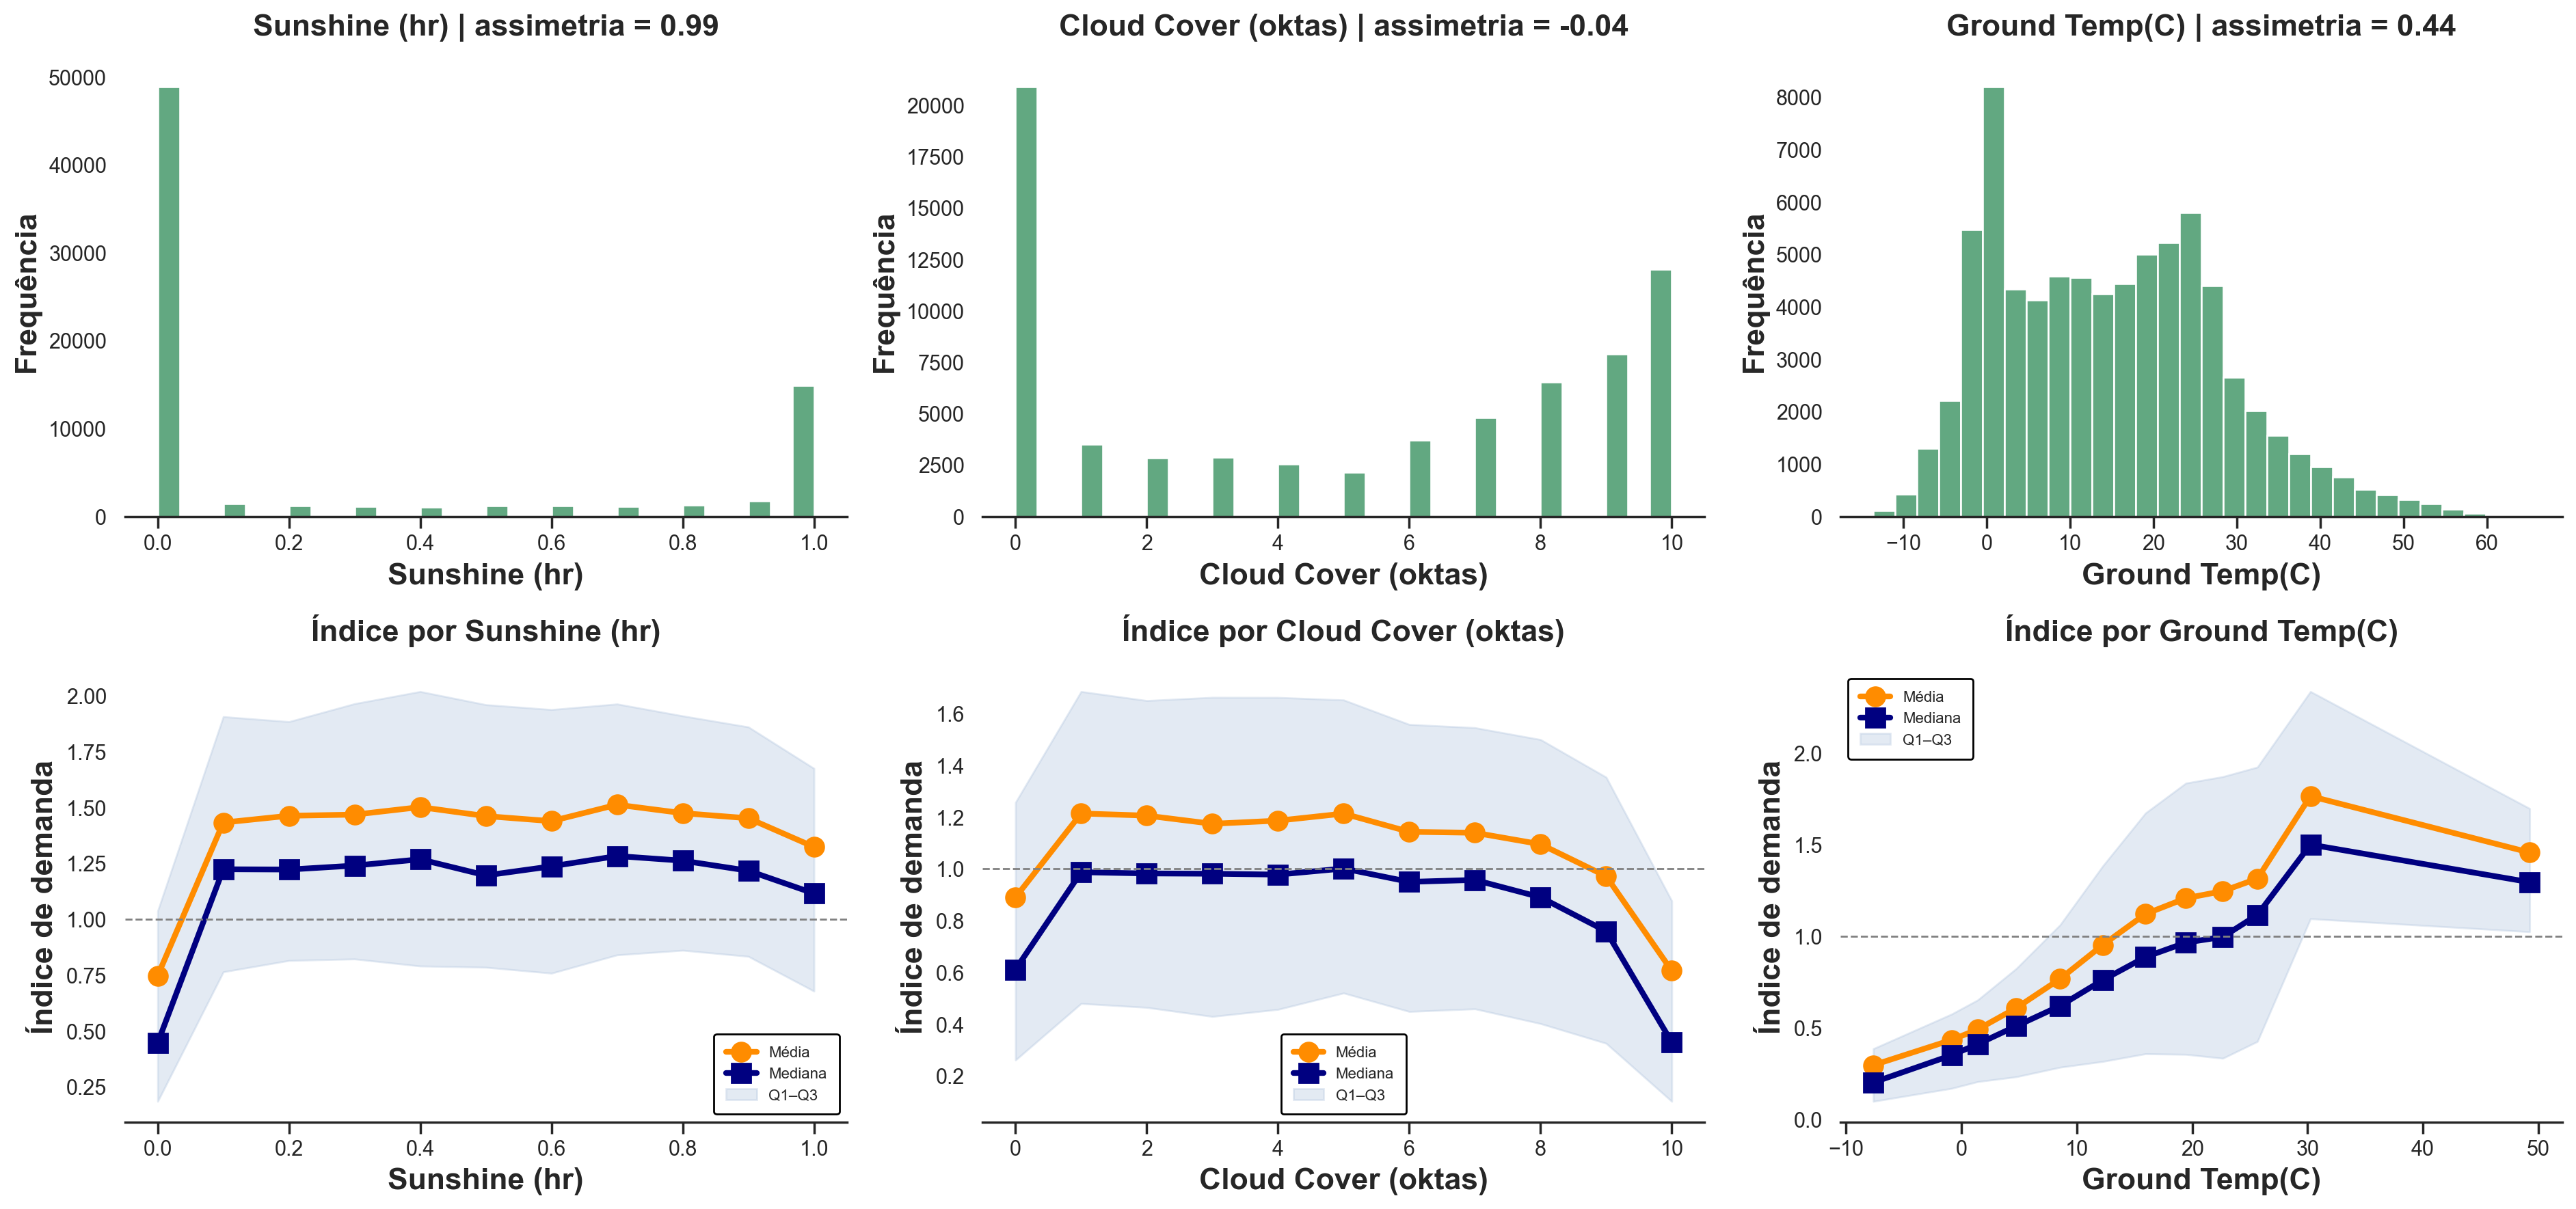

In [12]:
fig, axes = fe.plot_weather_relationships(mv, new_weather, INDEX, lang=lang)
plt.show()


>### Insight
>
> A associação monotônica mais alta com o índice foi observada para `Ground Temp(C)` (`ρ = 0,531`), seguida por `Sunshine (hr)` (`ρ = 0,397`). Para `Cloud Cover (oktas)`, a associação foi fraca e negativa (`ρ = -0,098`), embora diferenças não lineares entre faixas ainda possam ser exploradas por modelos flexíveis.
>
> Em `Cloud Cover (oktas)`, 7,26% das observações do quadro analítico permaneceram ausentes. A mediana não foi aplicada antes desta EDA, e a categoria ausente não foi confundida com céu limpo ou encoberto. Na modelagem, qualquer imputação deverá ser aprendida dentro dos folds temporais.
>
> A relação térmica não deve ser interpretada como contribuição independente, pois forte colinearidade entre temperatura do solo, temperatura do ar e ponto de orvalho já foi identificada no notebook 02. A decisão entre representações cruas e categorizadas será deixada aos seletores e ao desempenho fora da amostra.


## 5. Correspondência entre engenharia de atributos e espaço de modelagem

Nem toda coluna criada para diagnóstico precisa ser entregue automaticamente ao estimador. Por isso, é verificada abaixo a correspondência com as listas centrais de `RegressionOptimizer`. `Date` é preservada para ordenação e divisão temporal; `Year` não é usado como preditor direto, evitando que a identidade cronológica seja tratada como atalho para o nível crescente da operação.

`Sunshine Cat` e `Cloud Cover Cat` permanecem como representações descritivas nesta versão do espaço de busca. A primeira é quase determinística em relação à insolação contínua, e a segunda contém ausência relevante. Sua eventual inclusão deverá ser comparada de forma explícita e temporalmente validada, em vez de ser inferida apenas dos boxplots.


In [13]:
feature_audit = fe.feature_model_audit(df, lang=lang)
display(feature_audit)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='IProgress not found.*')
    from src.optimizer import RegressionOptimizer

model_features = set(RegressionOptimizer._NUMERICAL_FEATURES) | set(
    RegressionOptimizer._CATEGORICAL_FEATURES)
assert 'Rush_Period' in set(RegressionOptimizer._CATEGORICAL_FEATURES)
assert not ({'Date', 'Year'} & model_features)


,Variável criada,Derivada de,Disponível no modelo base,Papel
0,Date,DateTime + Hour,Não,Ordenação e validação temporal
1,Time_Period,Hour,Sim,Candidata aos seletores do otimizador
2,Weekday,Date,Sim,Candidata aos seletores do otimizador
3,DayNumberOnWeek,Date,Sim,Candidata aos seletores do otimizador
4,WeekStatus,Date,Sim,Candidata aos seletores do otimizador
5,Rush_Hour,Hour + WeekStatus + Holiday + Functioning Day,Sim,Candidata aos seletores do otimizador
6,Rush_Period,Hour + WeekStatus + Holiday + Functioning Day,Sim,Candidata aos seletores do otimizador
7,Rainfall Cat,Rainfall(mm),Sim,Candidata aos seletores do otimizador
8,Snowfall Cat,Snowfall (cm),Sim,Candidata aos seletores do otimizador
9,Sunshine Cat,Sunshine (hr),Não,EDA; candidata a comparação futura


>### Insight
>
> Foi confirmada a integração de `Rush_Period` ao conjunto categórico do otimizador. Sua permanência final não é imposta: ela será comparada com `Rush_Hour`, `Time_Period`, `Hour` e as demais variáveis pelos seletores configurados para cada estimador.
>
> `Date` e `Year` foram mantidos fora do espaço preditivo base. A primeira coluna é usada para preservar a estrutura temporal, enquanto a segunda poderia funcionar como identificador do crescimento histórico e produzir desempenho aparente sem garantir extrapolação para anos futuros.
>
> As categorias meteorológicas novas foram mantidas na EDA como representações alternativas. Como alta dependência foi observada entre variáveis contínuas e suas discretizações no notebook 02, sua inclusão automática apenas duplicaria informação antes de uma comparação controlada.


## 6. Síntese

A etapa de engenharia foi reavaliada em conjunto com o código do pipeline. Foram confirmadas 13 variáveis derivadas, os valores ausentes foram mantidos explícitos na EDA e a demanda bruta deixou de ser sobrescrita pelo índice des-tendenciado. A separação entre `Rented Bike Count` e `Demand_Index` tornou mais clara a fronteira entre o alvo operacional e a medida retrospectiva usada para comparação.

Um erro semântico foi corrigido em `Rush_Hour`: a condição de operação estava sendo interpretada como condição de dia útil, permitindo a classificação de fins de semana como pico. Pela regra revisada, foram exigidos dia de semana, operação ativa e ausência de feriado. Também foi criada `Rush_Period`, que separa os picos da manhã e da tarde/noite e apresentou a maior amplitude de medianas entre as features categóricas analisadas.

O índice baseado na média móvel centrada foi mantido apenas para EDA. A transformação removeu o crescimento de aproximadamente 106,8 vezes entre os anos extremos sem apagar a sazonalidade mensal, mas não pode ser usada como feature de previsão porque consulta o futuro. Os meses anômalos de maio a dezembro de 2020 foram excluídos somente da estimação da linha de base e permaneceram no quadro analisado.

Pela análise categórica, maior separação foi observada em `Rush_Period`, `Time_Period`, `Rush_Hour`, insolação e precipitação. A raridade das faixas intensas de chuva e neve e a interação dos efeitos com a estação impediram que os spreads fossem tratados como importância ajustada. Na inspeção do `MeanEncoder`, foi demonstrada a equivalência mecânica da média por nível, mas também foram explicitados o risco de vazamento e a instabilidade de médias não regularizadas em grupos pequenos.

Entre as novas medições meteorológicas, associação monotônica mais alta foi observada para temperatura do solo e insolação. Entretanto, colinearidade térmica e confundimento com horário e estação permaneceram presentes. Por esse motivo, exclusões manuais não foram impostas com base nesta EDA. A escolha será realizada dentro da validação temporal pelas alternativas `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` e `NoSelector`, condicionadas ao estimador e à transformação testados.

### Referências metodológicas

Micci-Barreca, D. (2001). *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems*. **ACM SIGKDD Explorations Newsletter, 3**(1), 27–32. https://doi.org/10.1145/507533.507538

Miller, D. M., & Williams, D. (2003). *Shrinkage estimators of time series seasonal factors and their effect on forecasting accuracy*. **International Journal of Forecasting, 19**(4), 669–684. https://doi.org/10.1016/S0169-2070(02)00077-8
